In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.append("/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis")
from cbm_datasets import CUB_112, CUB_312, FunnyBirdsCustom, get_transform_cub  # Import anpassen

In [2]:
ROOT_DIR_CUB = "/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets/CUB_200_2011"

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])[:, None, None]
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])[:, None, None]


def denormalize(img: np.ndarray) -> np.ndarray:
    """
    img: Tensor [3,H,W] normalized with ImageNet stats
    returns: numpy [H,W,3] in [0,1]
    """
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = img.clip(0, 1)
    return img.transpose(1, 2, 0)

In [ ]:
def plot_concept_scales(
    root_dir,
    img_id: int,
    concept_id_1: int,
    concept_id_2: int,
    transform,
):
    scales = ["small", "medium", "large"]

    # Datasets
    ds_none = CUB_112(
        root_dir=root_dir,
        mode="train",
        transform=transform,
        concept_masks_scale=None,
    )

    ds_scales = {
        s: CUB_112(
            root_dir=root_dir,
            mode="train",
            transform=transform,
            concept_masks_scale=s,
        )
        for s in scales
    }

    data_img = ds_none[img_id]
    img = denormalize(data_img["image"])

    fig, axes = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(14, 7),
        constrained_layout=True,
    )

    concept_ids = [concept_id_1, concept_id_2]
    concept_names = [ds_scales['small'].concepts[concept_id_1], ds_scales['small'].concepts[concept_id_2]]

    for row, cid in enumerate(concept_ids):
        # --- Original image ---
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f"Image\nConcept {concept_names[row]}")
        axes[row, 0].axis("off")

        # --- Masks ---
        for col, scale in enumerate(scales, start=1):
            data = ds_scales[scale][img_id]
            mask = data["mask_concepts"][cid]

            axes[row, col].imshow(mask, cmap="gray")
            axes[row, col].set_title(scale.capitalize())
            axes[row, col].axis("off")

    return fig


/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/.venv/lib64/python3.11/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for keypoints, but no transform to process it.
  self._set_keys()


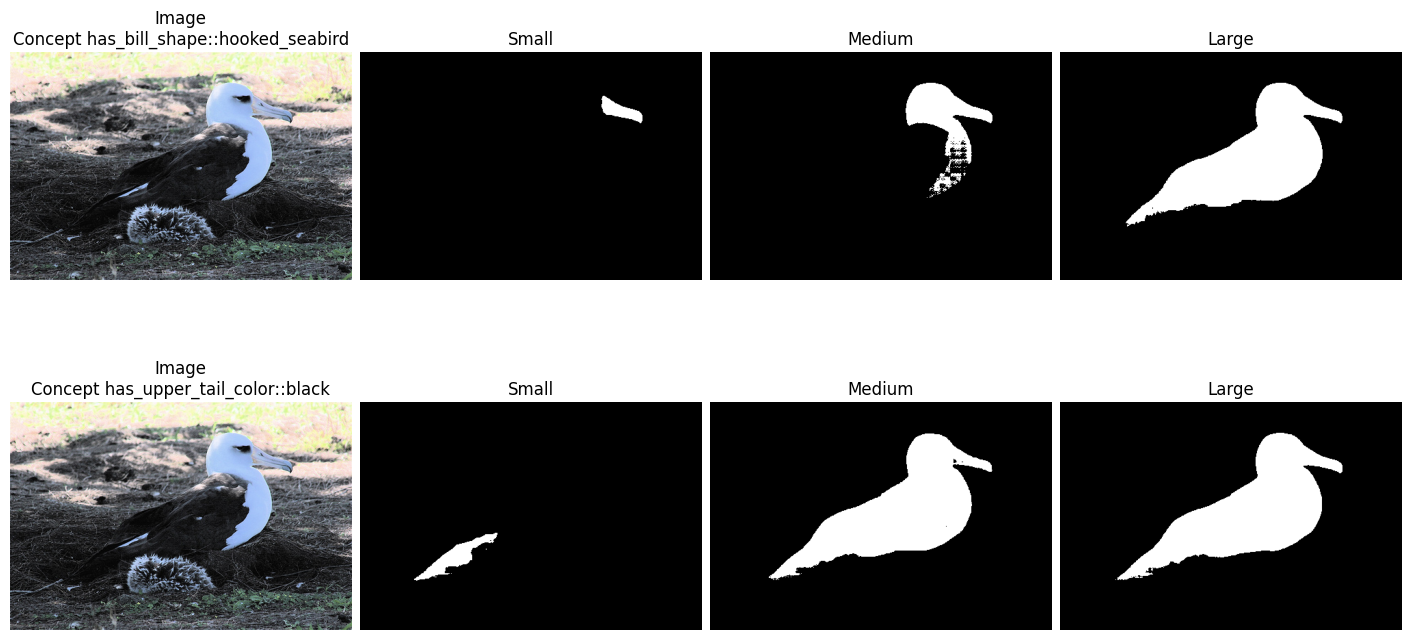

In [ ]:
transform = get_transform_cub(img_size=None, center_crop_size=None) # oder mit Crop

fig = plot_concept_scales(
    root_dir=ROOT_DIR_CUB,
    img_id=42,
    concept_id_1=1,
    concept_id_2=34,    # 
    transform=transform,
)

# plt.savefig("concept_scales.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
dataset_cb112 = CUB_112(
    root_dir=ROOT_DIR_CUB,
    mode="train",
    transform=transform,
    concept_masks_scale="small",
)

In [ ]:
bird = dataset_cb112[42]

In [ ]:
np.where(bird['mask_concepts'].sum(axis=(1,2)))

(array([  1,   7,  13,  20,  22,  28,  34,  43,  48,  50,  51,  58,  61,
         68,  79,  86,  93,  94, 107, 108]),)

# Restnet 50 Grid

In [ ]:
from torchvision import models
import torch
import torch.nn as nn

In [ ]:
res = models.resnet50()

In [ ]:
backbone = nn.Sequential(
            res.conv1,
            res.bn1,
            res.relu,
            res.maxpool,
            res.layer1,
            res.layer2,
            res.layer3,
            res.layer4,
        )

In [ ]:
pred = backbone(torch.randn((1,3,256,256)))

In [ ]:
pred.shape

torch.Size([1, 2048, 8, 8])

In [ ]:
ROOT_DIR_FUNNY_BIRDS = "/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets/FunnyBirds"
dataset_fb = FunnyBirdsCustom(ROOT_DIR_FUNNY_BIRDS, 'test', transform=transform)
idx = 303
img = denormalize(dataset_cb112[idx]['image'])

In [ ]:
dataset_cb112[idx].keys()

dict_keys(['class_idx', 'image_id', 'image', 'concepts', 'concept_coords', 'concept_point_mask', 'labels', 'mask_foreground', 'mask_concepts'])

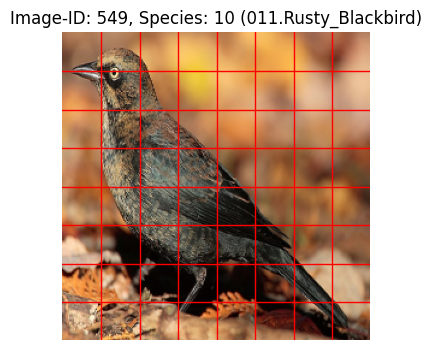

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

plt.figure(figsize=(4, 4))
img = cv2.resize(img, (256, 256))
plt.imshow(img)
plt.axis("off")
grid_size = 8
cell = img.shape[0] // grid_size  # 32

for i in range(1, grid_size):
    plt.axvline(i * cell, color="red", linewidth=1)
    plt.axhline(i * cell, color="red", linewidth=1)

plt.title(f"Image-ID: {dataset_cb112[idx]['image_id']}, Species: {np.argmax(dataset_cb112[idx]['labels'])} ({dataset_cb112.classes.iloc[np.argmax(dataset_cb112[idx]['labels'])]['class_name']})")

plt.show()


In [ ]:
import timm
from architecture.upsampler_modules import get_upsampler_by_name

In [ ]:
def get_dinov3_timm():
    model_type = "base"  # 'small', 'base', or 'large'
    model = timm.create_model(
        f"vit_{model_type}_patch16_dinov3.lvd1689m",
        pretrained=True,
        features_only=True,
        out_indices=(-1,),
        cache_dir="/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache",
    )
    for p in model.parameters():
        p.requires_grad = False

    # get model specific transforms (normalization, resize)
    # data_config = timm.data.resolve_model_data_config(fmodel)
    # transforms = timm.data.create_transform(**data_config, is_training=False)

    return model

In [ ]:
dinov3 = get_dinov3_timm()
anyup = get_upsampler_by_name(name='anyup')

dinov3.eval()
anyup.eval()

print("")

Using cache found in /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/.cache/hub/wimmerth_anyup_main


In [ ]:
idx = 10
img = dataset_cb112[idx]['image']
img = torch.Tensor(img[None,:]).contiguous()

with torch.no_grad():
    features_lr = dinov3(img)[0]
    print("Dino done")
    features_hr = anyup(img, features_lr)[0]

Dino done


In [ ]:
features_hr.shape

torch.Size([768, 240, 320])

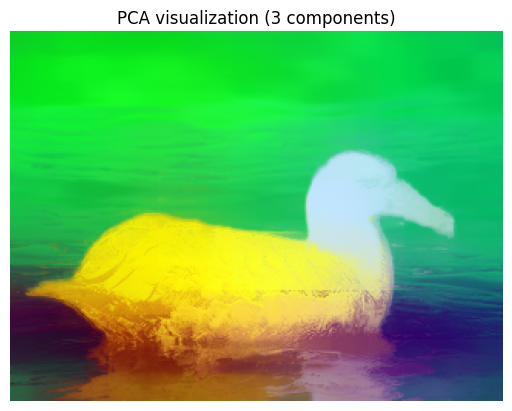

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

C, H, W = features_hr.shape

# --- PCA over channels ---
# reshape to (H*W, C)
pixels = features_hr.numpy().reshape(C, -1).T  # (65536, 768)

pca = PCA(n_components=3)
pca_feats = pca.fit_transform(pixels)  # (H*W, 3)

# normalize for visualization
pca_vis = (pca_feats - pca_feats.min(0)) / (pca_feats.max(0) - pca_feats.min(0))
pca_img = pca_vis.reshape(H, W, 3)

plt.figure()
plt.imshow(pca_img)
plt.title("PCA visualization (3 components)")
plt.axis("off")
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np


def denormalize_imagenet(img: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.485, 0.456, 0.406], device=img.device)[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225], device=img.device)[:, None, None]
    return (img * std + mean).clamp(0, 1)



import torch
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np


def plot_similarities(
    features_hr: torch.Tensor,      # [D, H, W]
    features_lr: torch.Tensor,      # [D, h, w]
    img_rgb: torch.Tensor,          # [3, H, W] (ImageNet-normalized)
    x: int,
    y: int,
    thresholds: list[float],
    alpha: float = 0.55,
    center_features: bool = False,
):
    """
    Paper-style similarity visualization.
    Row 1: HR features
    Row 2: LR features (same semantic point, rescaled coordinates)
    """

    def compute_similarity_map(features, px, py, center):
        D, H, W = features.shape

        if center:
            mean_feat = features.mean(dim=(1, 2), keepdim=True)
            features = features - mean_feat

        feats = features / (features.norm(dim=0, keepdim=True) + 1e-8)

        ref = feats[:, py, px]                  # [D]
        all_feats = feats.view(D, -1).T         # [H*W, D]
        sim = all_feats @ ref                   # cosine similarity

        return sim.view(H, W)

    # ------------------------------------------------
    # Coordinate mapping HR → LR
    # ------------------------------------------------
    _, H_hr, W_hr = features_hr.shape
    _, H_lr, W_lr = features_lr.shape

    x_lr = int(round(x * W_lr / W_hr))
    y_lr = int(round(y * H_lr / H_hr))

    # ------------------------------------------------
    # Similarities
    # ------------------------------------------------
    sim_hr = compute_similarity_map(features_hr, x, y, center_features).cpu()
    sim_lr = compute_similarity_map(features_lr, x_lr, y_lr, center_features).cpu()

    # ------------------------------------------------
    # Background image
    # ------------------------------------------------
    img_bg = denormalize_imagenet(img_rgb).permute(1, 2, 0).cpu().numpy()

    # ------------------------------------------------
    # Plot setup
    # ------------------------------------------------
    n_img_cols = 1 + len(thresholds)
    fig = plt.figure(figsize=(3.8 * n_img_cols + 3.5, 7.2), constrained_layout=True)

    gs = fig.add_gridspec(2, n_img_cols + 1, width_ratios=[1]*n_img_cols + [0.9])

    axes = np.empty((2, n_img_cols), dtype=object)
    for r in range(2):
        for c in range(n_img_cols):
            axes[r, c] = fig.add_subplot(gs[r, c])

    ax_dist = fig.add_subplot(gs[:, -1])  # spans both rows


    # Consistent color normalization per row
    norm_hr = colors.Normalize(vmin=sim_hr.min().item(), vmax=sim_hr.max().item())
    norm_lr = colors.Normalize(vmin=sim_lr.min().item(), vmax=sim_lr.max().item())

    # ------------------------------------------------
    # Row 1: HR
    # ------------------------------------------------
    axes[0, 0].imshow(img_bg)
    im_hr = axes[0, 0].imshow(sim_hr, alpha=alpha, norm=norm_hr, cmap="viridis")
    axes[0, 0].scatter(x, y, c="red", marker="x", s=90, linewidths=2)
    axes[0, 0].set_title("HR – Cosine similarity")
    axes[0, 0].axis("off")

    for j, thr in enumerate(thresholds, start=1):
        mask = (sim_hr >= thr)
        axes[0, j].imshow(img_bg)
        axes[0, j].imshow(mask, alpha=alpha, cmap="gray")
        axes[0, j].scatter(x, y, c="red", marker="x", s=90, linewidths=2)
        axes[0, j].set_title(f"HR ≥ {thr:.2f}")
        axes[0, j].axis("off")

    # ------------------------------------------------
    # Row 2: LR
    # ------------------------------------------------
    im_lr = axes[1, 0].imshow(sim_lr, norm=norm_lr, cmap="viridis")
    axes[1, 0].scatter(x_lr, y_lr, c="red", marker="x", s=90, linewidths=2)
    axes[1, 0].set_title("LR – Cosine similarity")
    axes[1, 0].axis("off")

    for j, thr in enumerate(thresholds, start=1):
        mask = (sim_lr >= thr)
        axes[1, j].imshow(mask, cmap="gray")
        axes[1, j].scatter(x_lr, y_lr, c="red", marker="x", s=90, linewidths=2)
        axes[1, j].set_title(f"LR ≥ {thr:.2f}")
        axes[1, j].axis("off")

    # ------------------------------------------------
    # Distribution plot (HR vs LR)
    # ------------------------------------------------
    bins = np.linspace(-1.0, 1.0, 60)

    ax_dist.hist(
        sim_hr.flatten().numpy(),
        bins=bins,
        density=True,
        alpha=0.55,
        label="HR",
        orientation="horizontal",
    )

    ax_dist.hist(
        sim_lr.flatten().numpy(),
        bins=bins,
        density=True,
        alpha=0.55,
        label="LR",
        orientation="horizontal",
    )

    ax_dist.set_ylim(-1, 1)
    ax_dist.set_xlabel("Density")
    ax_dist.set_ylabel("Cosine similarity")
    ax_dist.set_title("Similarity distribution")

    ax_dist.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax_dist.legend(frameon=False)

    ax_dist.axhline(1.0, color="red", linewidth=1.2, linestyle=":")


    # ------------------------------------------------
    # Colorbars (one per row, paper-style)
    # ------------------------------------------------
    fig.colorbar(im_hr, ax=axes[0, :], location="right", shrink=0.85)
    fig.colorbar(im_lr, ax=axes[1, :], location="right", shrink=0.85)

    plt.show()

    return sim_hr, sim_hr


In [ ]:
features_hr.shape

torch.Size([768, 240, 320])

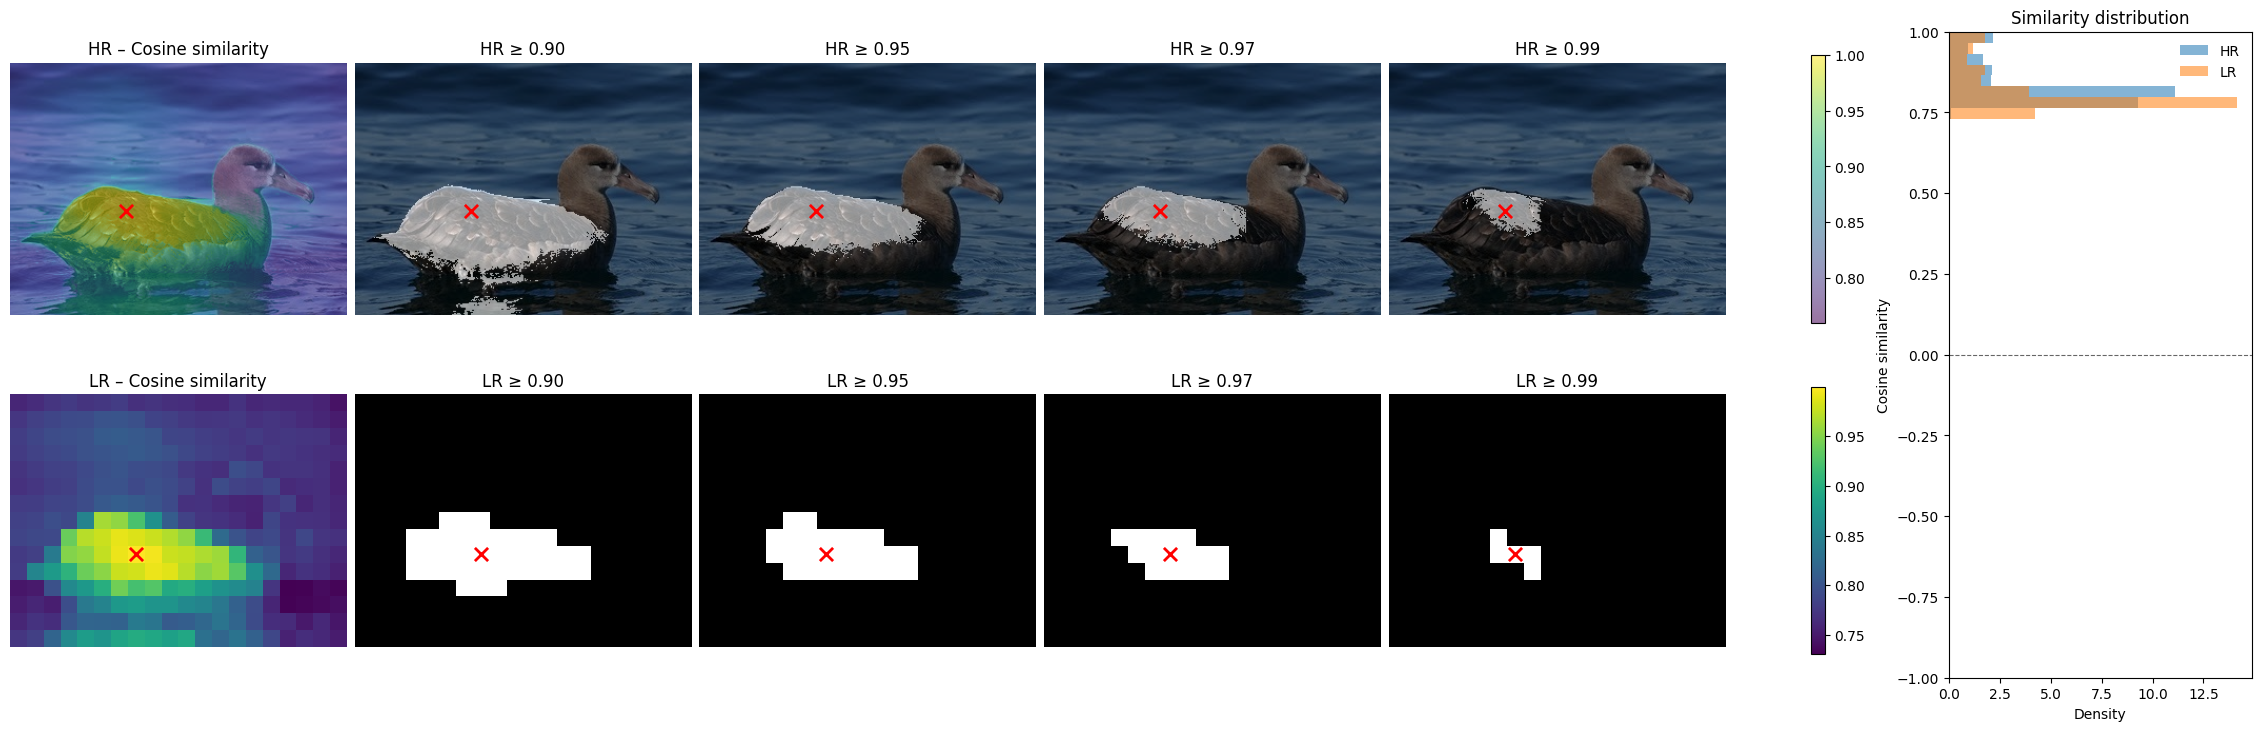

(tensor([[0.7781, 0.7794, 0.7796,  ..., 0.7662, 0.7662, 0.7650],
         [0.7785, 0.7817, 0.7819,  ..., 0.7669, 0.7667, 0.7636],
         [0.7785, 0.7817, 0.7818,  ..., 0.7661, 0.7659, 0.7629],
         ...,
         [0.7911, 0.7956, 0.7958,  ..., 0.7713, 0.7723, 0.7712],
         [0.7914, 0.7963, 0.7961,  ..., 0.7728, 0.7734, 0.7700],
         [0.7907, 0.7936, 0.7940,  ..., 0.7744, 0.7737, 0.7718]]),
 tensor([[0.7781, 0.7794, 0.7796,  ..., 0.7662, 0.7662, 0.7650],
         [0.7785, 0.7817, 0.7819,  ..., 0.7669, 0.7667, 0.7636],
         [0.7785, 0.7817, 0.7818,  ..., 0.7661, 0.7659, 0.7629],
         ...,
         [0.7911, 0.7956, 0.7958,  ..., 0.7713, 0.7723, 0.7712],
         [0.7914, 0.7963, 0.7961,  ..., 0.7728, 0.7734, 0.7700],
         [0.7907, 0.7936, 0.7940,  ..., 0.7744, 0.7737, 0.7718]]))

In [ ]:
# Referenzpixel
x, y = 110, 140
plot_similarities(features_hr=features_hr, features_lr=features_lr[0], img_rgb=img[0], x=x, y=y, thresholds=[0.9, 0.95, 0.97, 0.99],)

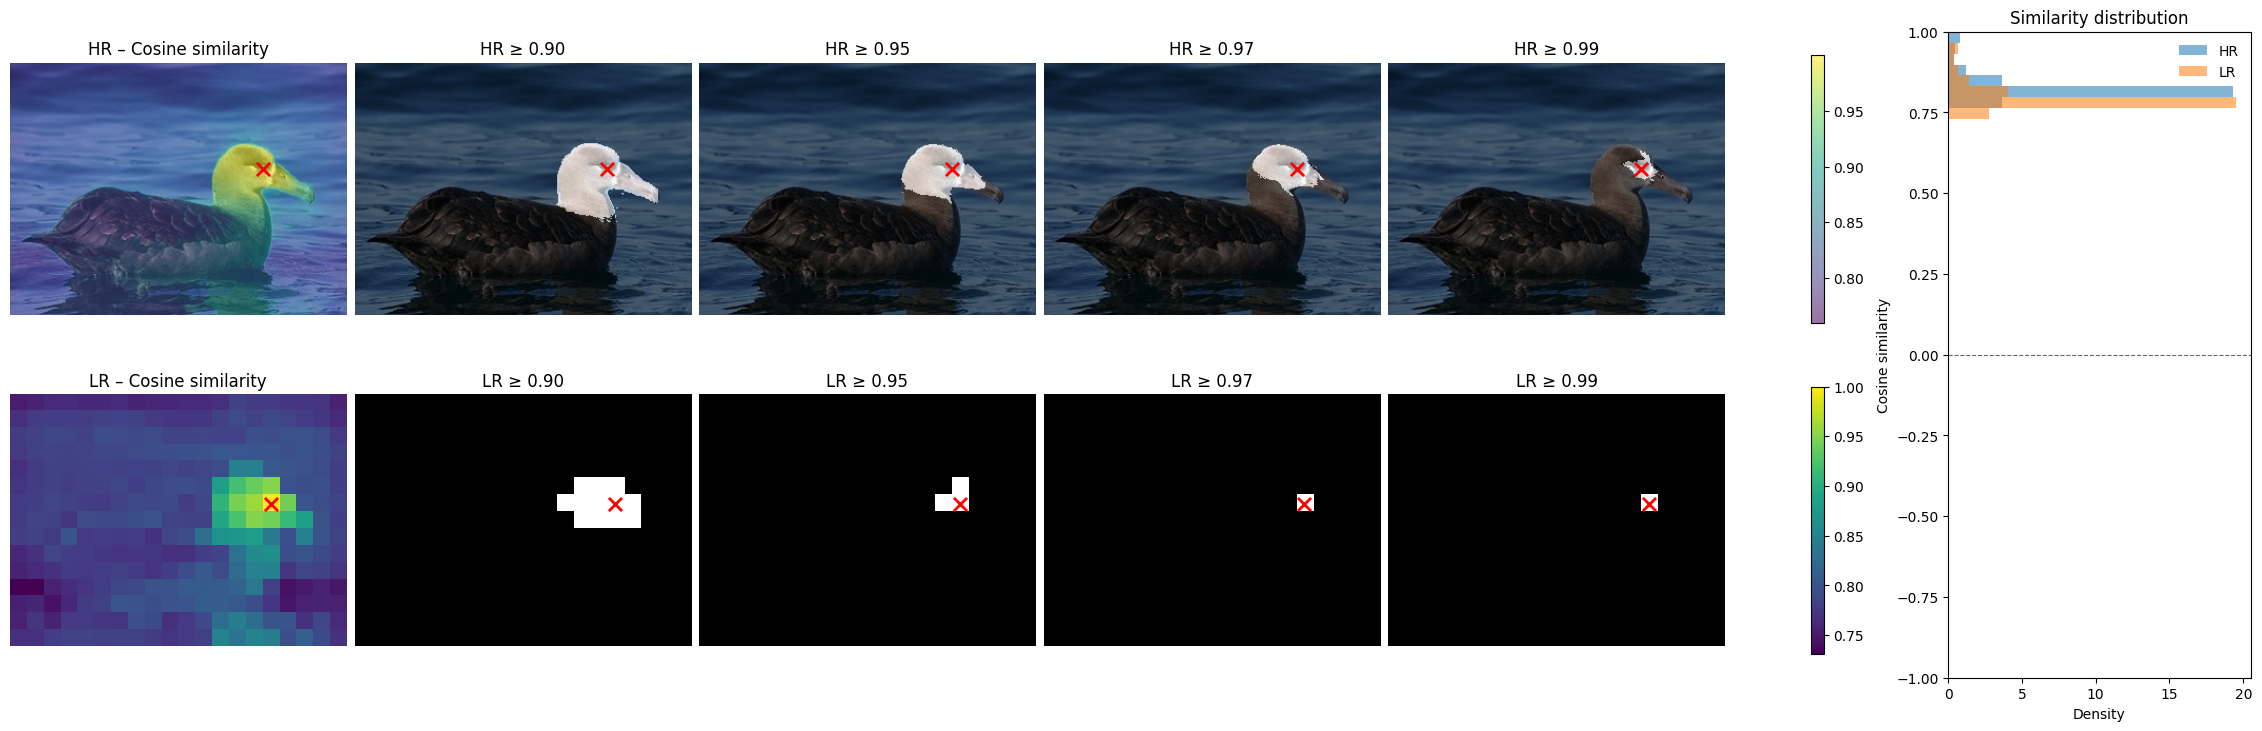

(tensor([[0.7746, 0.7758, 0.7759,  ..., 0.7826, 0.7825, 0.7814],
         [0.7750, 0.7780, 0.7782,  ..., 0.7833, 0.7831, 0.7800],
         [0.7750, 0.7779, 0.7780,  ..., 0.7825, 0.7824, 0.7793],
         ...,
         [0.7911, 0.7941, 0.7943,  ..., 0.7951, 0.7966, 0.7950],
         [0.7914, 0.7946, 0.7944,  ..., 0.7973, 0.7983, 0.7930],
         [0.7907, 0.7926, 0.7928,  ..., 0.8004, 0.7991, 0.7960]]),
 tensor([[0.7746, 0.7758, 0.7759,  ..., 0.7826, 0.7825, 0.7814],
         [0.7750, 0.7780, 0.7782,  ..., 0.7833, 0.7831, 0.7800],
         [0.7750, 0.7779, 0.7780,  ..., 0.7825, 0.7824, 0.7793],
         ...,
         [0.7911, 0.7941, 0.7943,  ..., 0.7951, 0.7966, 0.7950],
         [0.7914, 0.7946, 0.7944,  ..., 0.7973, 0.7983, 0.7930],
         [0.7907, 0.7926, 0.7928,  ..., 0.8004, 0.7991, 0.7960]]))

In [ ]:
# Referenzpixel
x, y = 240, 100
plot_similarities(features_hr=features_hr, features_lr=features_lr[0], img_rgb=img[0], x=x, y=y, thresholds=[0.9, 0.95, 0.97, 0.99],)

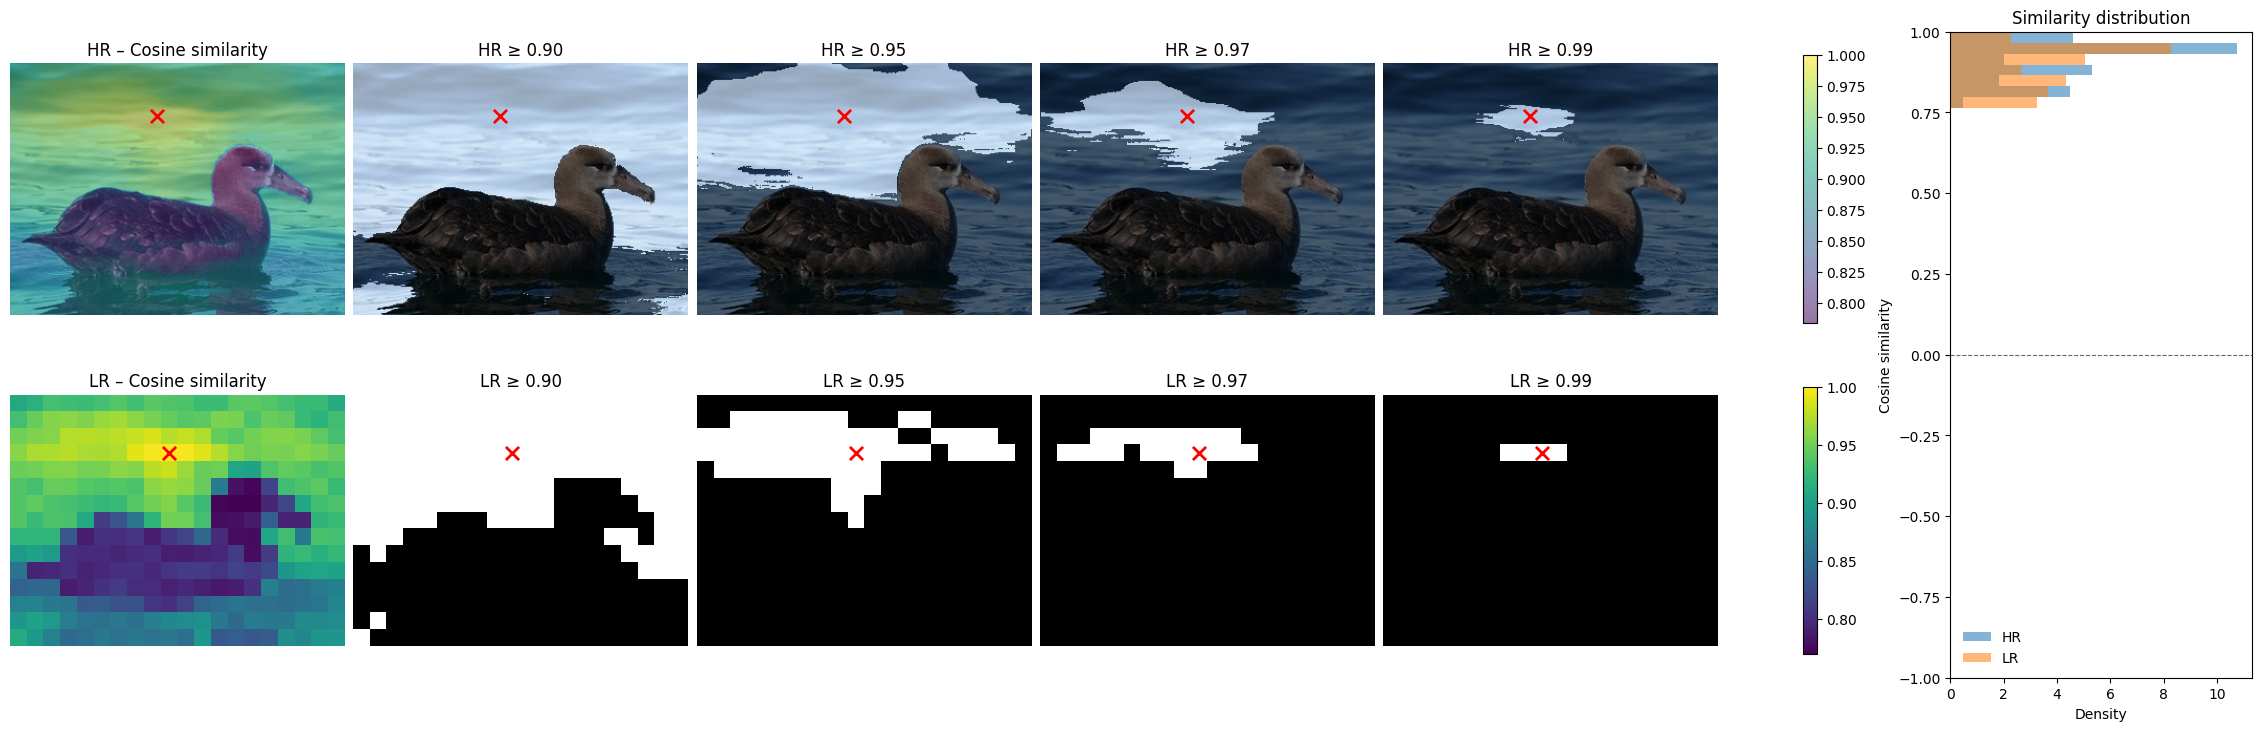

(tensor([[0.9224, 0.9244, 0.9246,  ..., 0.9267, 0.9267, 0.9256],
         [0.9229, 0.9278, 0.9281,  ..., 0.9274, 0.9273, 0.9241],
         [0.9229, 0.9278, 0.9279,  ..., 0.9266, 0.9265, 0.9234],
         ...,
         [0.9206, 0.9208, 0.9208,  ..., 0.9021, 0.9026, 0.9021],
         [0.9207, 0.9208, 0.9208,  ..., 0.9027, 0.9029, 0.9015],
         [0.9204, 0.9206, 0.9206,  ..., 0.9034, 0.9031, 0.9024]]),
 tensor([[0.9224, 0.9244, 0.9246,  ..., 0.9267, 0.9267, 0.9256],
         [0.9229, 0.9278, 0.9281,  ..., 0.9274, 0.9273, 0.9241],
         [0.9229, 0.9278, 0.9279,  ..., 0.9266, 0.9265, 0.9234],
         ...,
         [0.9206, 0.9208, 0.9208,  ..., 0.9021, 0.9026, 0.9021],
         [0.9207, 0.9208, 0.9208,  ..., 0.9027, 0.9029, 0.9015],
         [0.9204, 0.9206, 0.9206,  ..., 0.9034, 0.9031, 0.9024]]))

In [ ]:
# Referenzpixel
x, y = 140, 50
plot_similarities(features_hr=features_hr, features_lr=features_lr[0], img_rgb=img[0], x=x, y=y, thresholds=[0.9, 0.95, 0.97, 0.99],)

## FunnyBirds

In [ ]:
idx = 10
img = dataset_fb[idx]['image']
img = torch.Tensor(img[None,:]).contiguous()

with torch.no_grad():
    features_lr = dinov3(img)[0]
    print("Dino done")
    features_hr = anyup(img, features_lr)[0]
    features_lr = features_lr[0]

Dino done


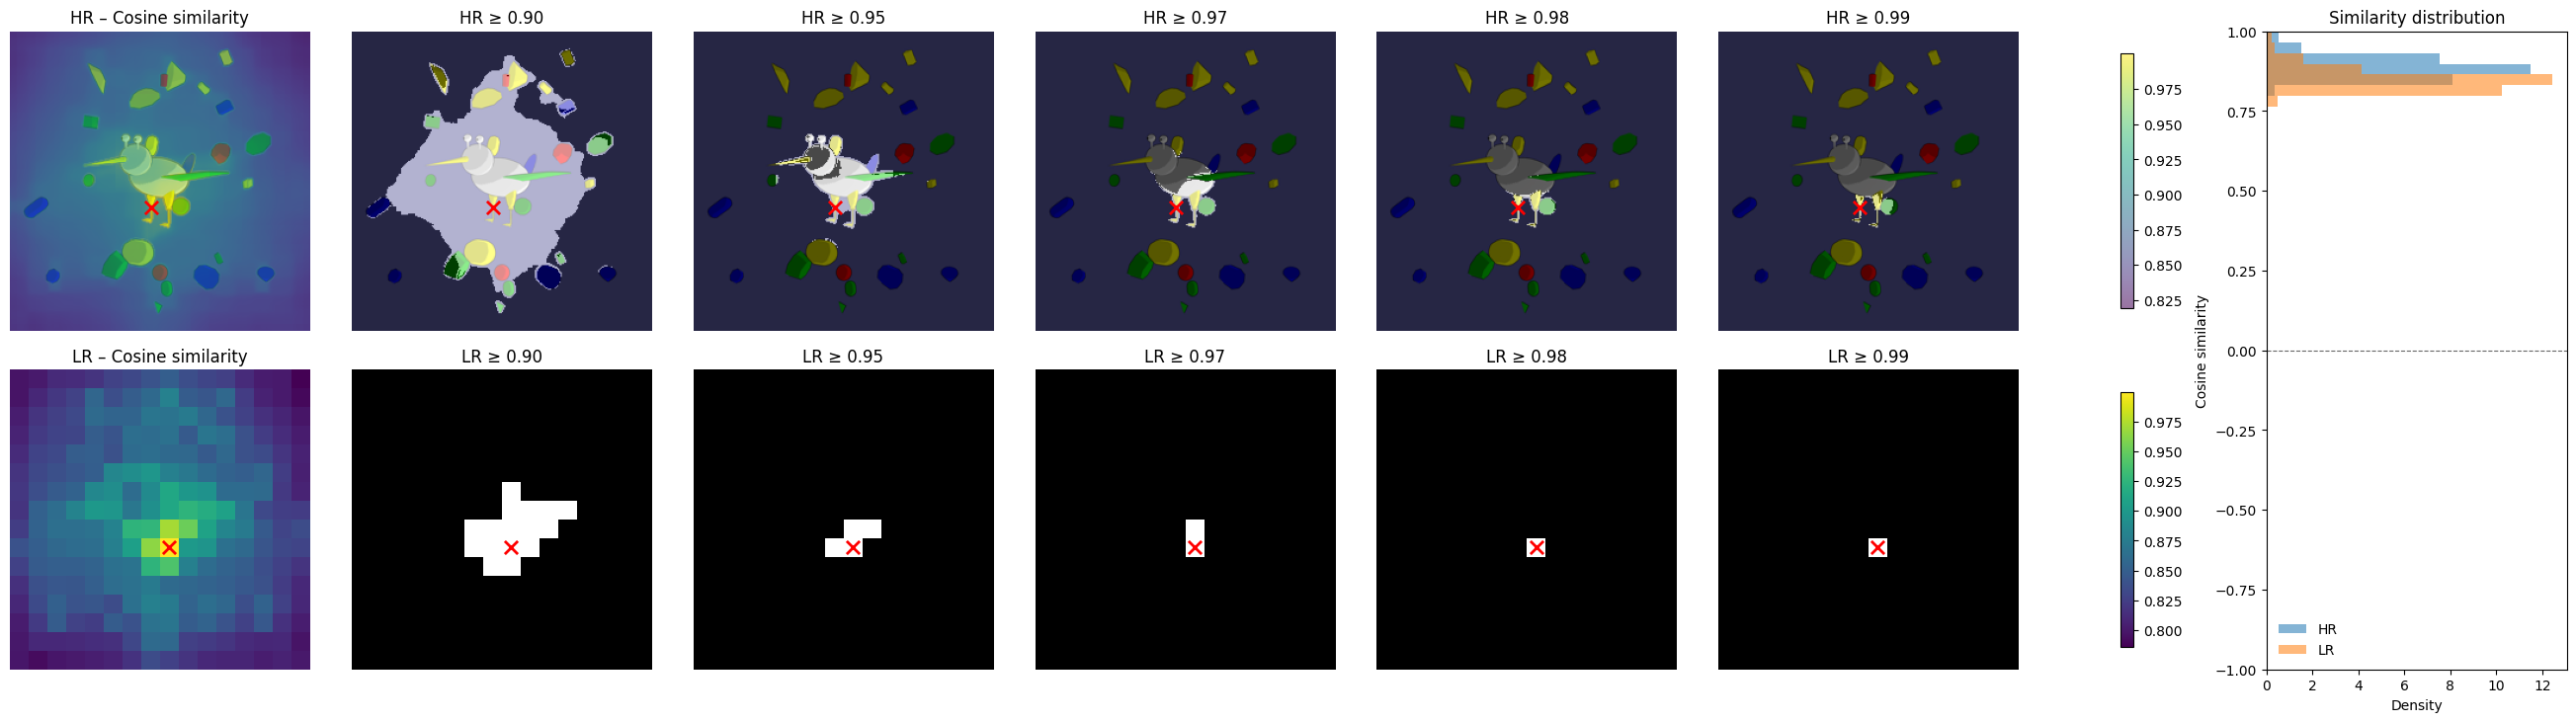

(tensor([[0.8265, 0.8268, 0.8269,  ..., 0.8199, 0.8199, 0.8207],
         [0.8275, 0.8288, 0.8289,  ..., 0.8191, 0.8191, 0.8193],
         [0.8275, 0.8289, 0.8290,  ..., 0.8192, 0.8192, 0.8194],
         ...,
         [0.8326, 0.8339, 0.8339,  ..., 0.8372, 0.8371, 0.8352],
         [0.8325, 0.8339, 0.8339,  ..., 0.8372, 0.8371, 0.8352],
         [0.8322, 0.8324, 0.8324,  ..., 0.8369, 0.8368, 0.8355]]),
 tensor([[0.8265, 0.8268, 0.8269,  ..., 0.8199, 0.8199, 0.8207],
         [0.8275, 0.8288, 0.8289,  ..., 0.8191, 0.8191, 0.8193],
         [0.8275, 0.8289, 0.8290,  ..., 0.8192, 0.8192, 0.8194],
         ...,
         [0.8326, 0.8339, 0.8339,  ..., 0.8372, 0.8371, 0.8352],
         [0.8325, 0.8339, 0.8339,  ..., 0.8372, 0.8371, 0.8352],
         [0.8322, 0.8324, 0.8324,  ..., 0.8369, 0.8368, 0.8355]]))

In [ ]:
# Referenzpixel
x, y = 120, 150
plot_similarities(features_hr=features_hr, features_lr=features_lr, img_rgb=img[0], x=x, y=y, thresholds=[0.9, 0.95, 0.97, 0.98, 0.99])

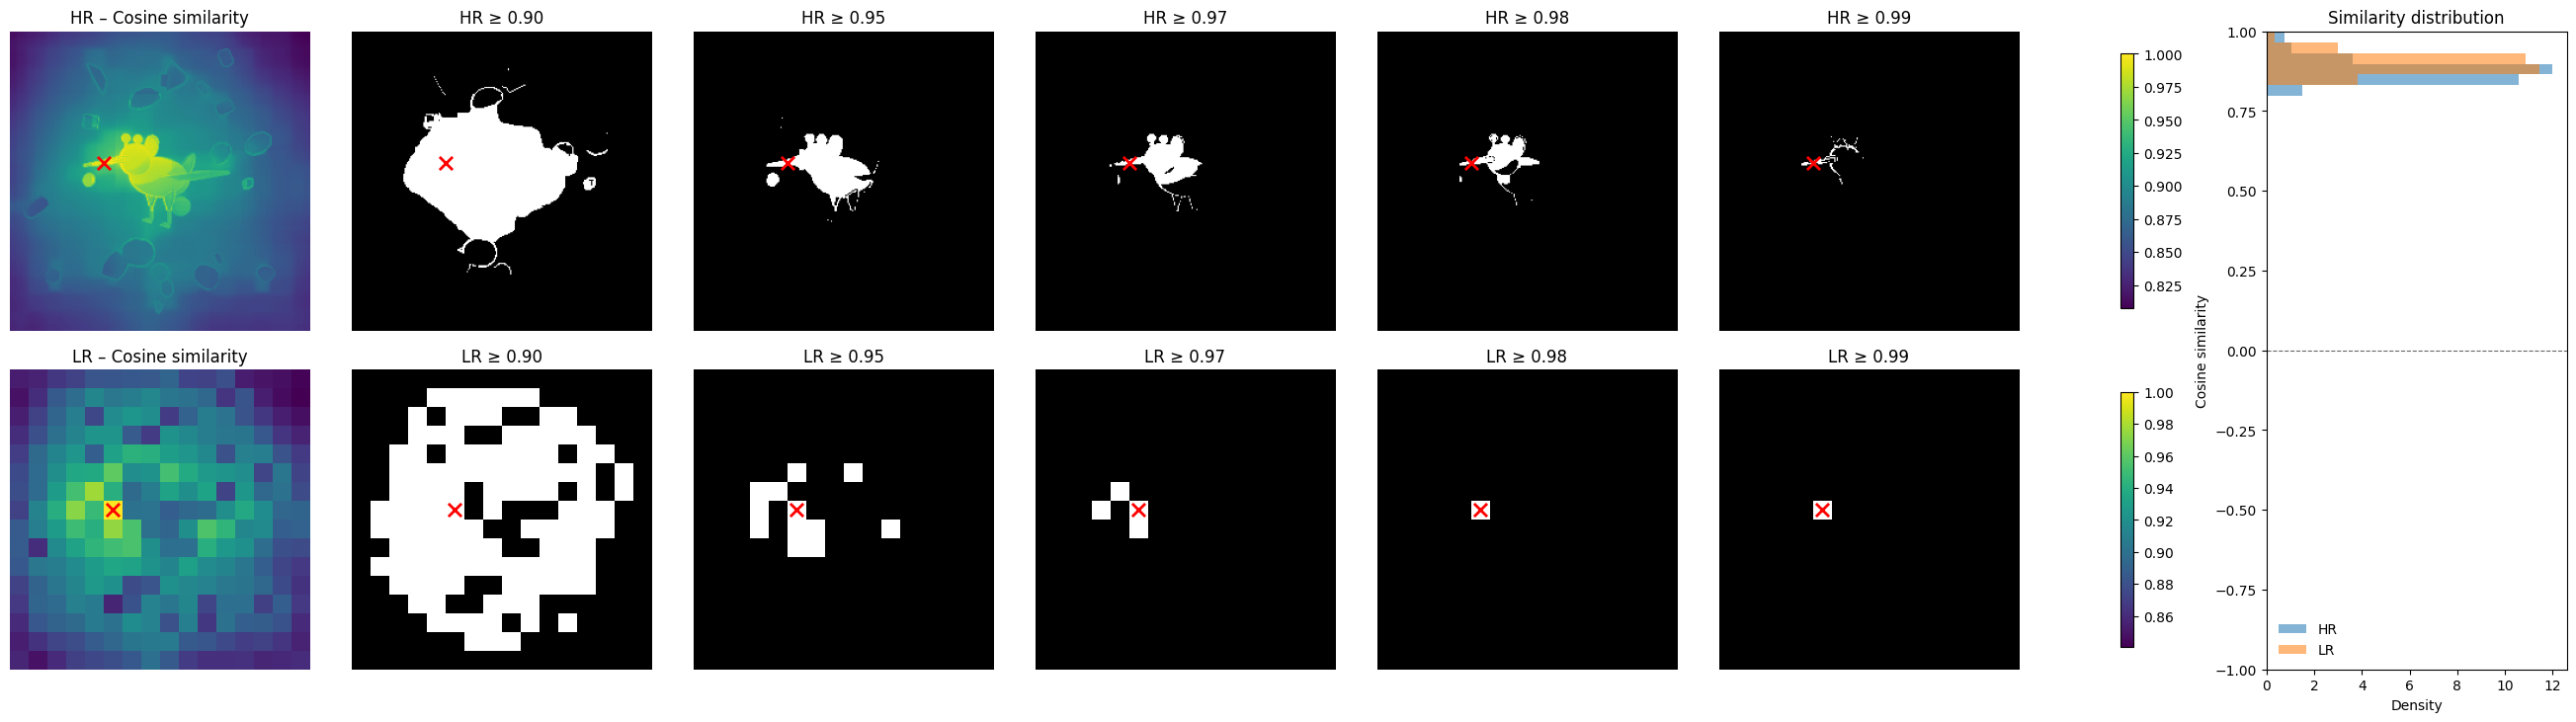

(tensor([[0.8123, 0.8127, 0.8128,  ..., 0.8082, 0.8082, 0.8090],
         [0.8133, 0.8148, 0.8149,  ..., 0.8073, 0.8073, 0.8075],
         [0.8133, 0.8149, 0.8150,  ..., 0.8074, 0.8074, 0.8076],
         ...,
         [0.8265, 0.8279, 0.8279,  ..., 0.8335, 0.8334, 0.8315],
         [0.8265, 0.8279, 0.8279,  ..., 0.8335, 0.8334, 0.8315],
         [0.8262, 0.8265, 0.8265,  ..., 0.8332, 0.8331, 0.8318]]),
 tensor([[0.8123, 0.8127, 0.8128,  ..., 0.8082, 0.8082, 0.8090],
         [0.8133, 0.8148, 0.8149,  ..., 0.8073, 0.8073, 0.8075],
         [0.8133, 0.8149, 0.8150,  ..., 0.8074, 0.8074, 0.8076],
         ...,
         [0.8265, 0.8279, 0.8279,  ..., 0.8335, 0.8334, 0.8315],
         [0.8265, 0.8279, 0.8279,  ..., 0.8335, 0.8334, 0.8315],
         [0.8262, 0.8265, 0.8265,  ..., 0.8332, 0.8331, 0.8318]]))

In [ ]:
# Referenzpixel
x, y = 80, 112
plot_similarities(features_hr=features_hr, features_lr=features_lr, img_rgb=img[0], x=x, y=y, thresholds=[0.9, 0.95, 0.97, 0.98, 0.99], alpha=1)

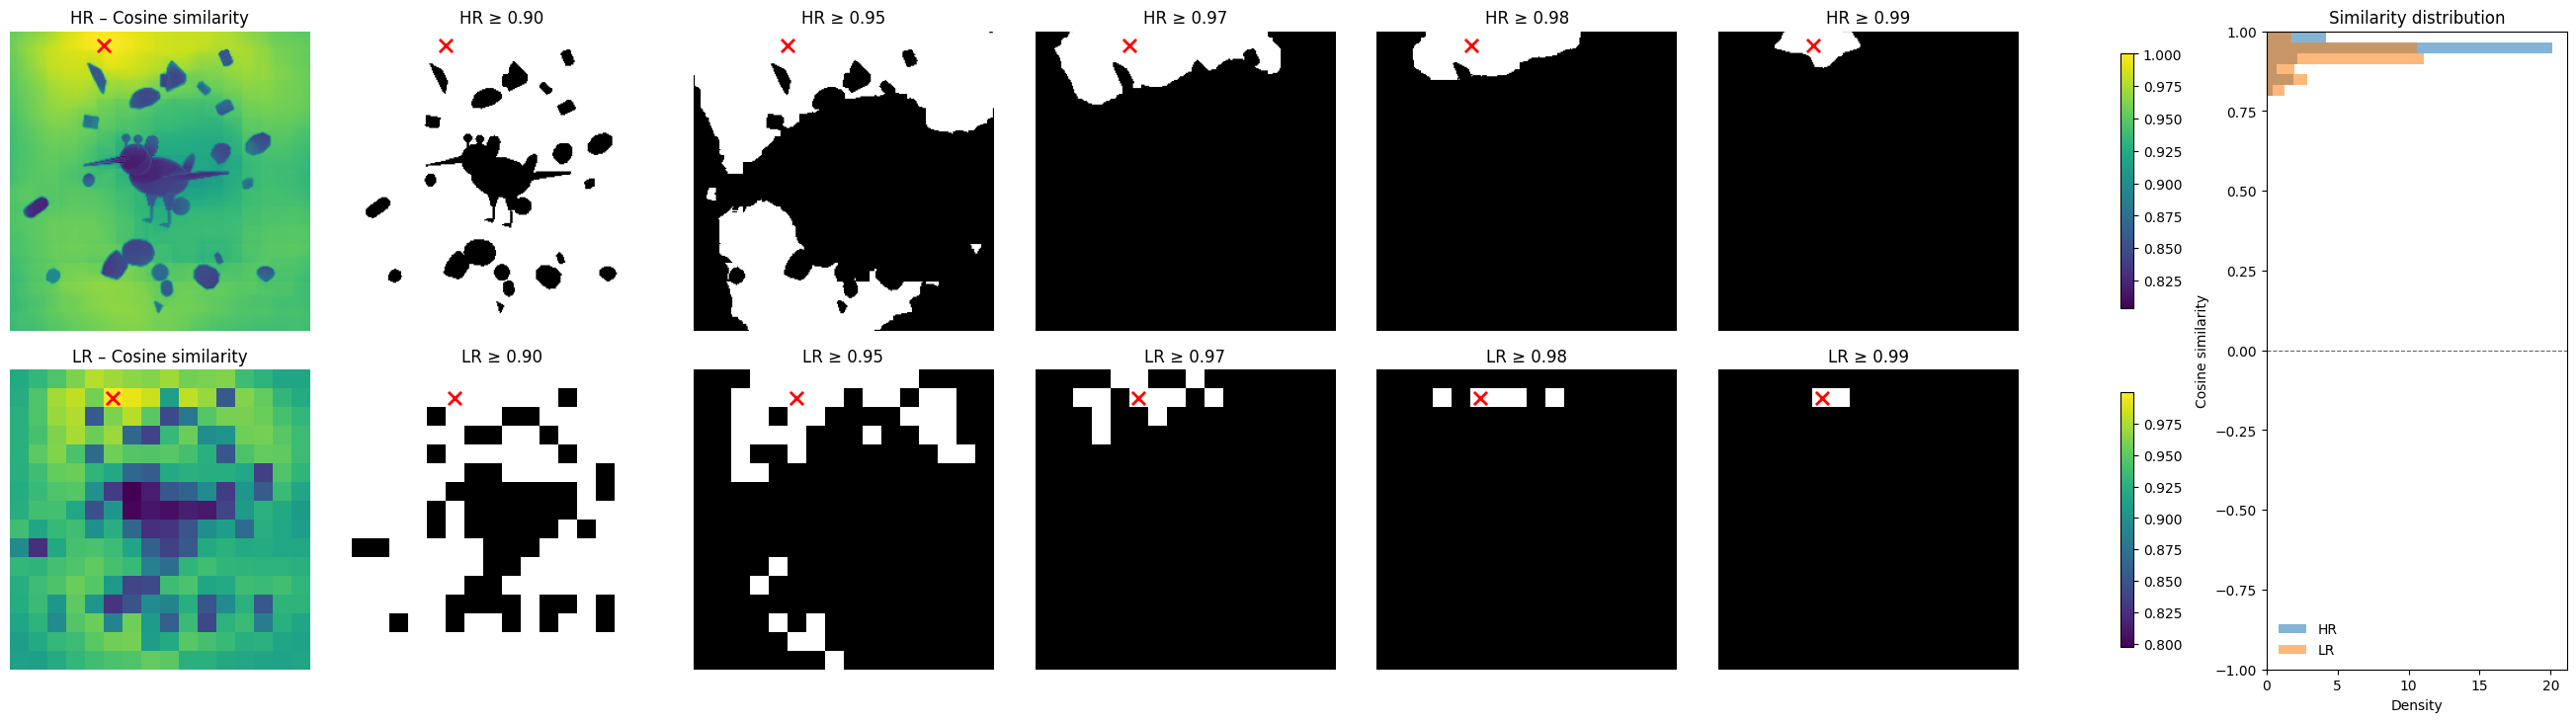

(tensor([[0.9526, 0.9531, 0.9532,  ..., 0.9501, 0.9501, 0.9508],
         [0.9536, 0.9554, 0.9555,  ..., 0.9499, 0.9499, 0.9502],
         [0.9537, 0.9555, 0.9556,  ..., 0.9501, 0.9500, 0.9503],
         ...,
         [0.9351, 0.9369, 0.9370,  ..., 0.9392, 0.9392, 0.9379],
         [0.9351, 0.9369, 0.9369,  ..., 0.9392, 0.9392, 0.9379],
         [0.9348, 0.9354, 0.9355,  ..., 0.9388, 0.9388, 0.9380]]),
 tensor([[0.9526, 0.9531, 0.9532,  ..., 0.9501, 0.9501, 0.9508],
         [0.9536, 0.9554, 0.9555,  ..., 0.9499, 0.9499, 0.9502],
         [0.9537, 0.9555, 0.9556,  ..., 0.9501, 0.9500, 0.9503],
         ...,
         [0.9351, 0.9369, 0.9370,  ..., 0.9392, 0.9392, 0.9379],
         [0.9351, 0.9369, 0.9369,  ..., 0.9392, 0.9392, 0.9379],
         [0.9348, 0.9354, 0.9355,  ..., 0.9388, 0.9388, 0.9380]]))

In [ ]:
# Referenzpixel
x, y = 80, 12
plot_similarities(features_hr=features_hr, features_lr=features_lr, img_rgb=img[0], x=x, y=y, thresholds=[0.9, 0.95, 0.97, 0.98, 0.99], alpha=1)

# Segmentation

In [23]:
import os

import pandas as pd
from tqdm import tqdm

import wandb

# Konfiguration
CSV_PATH = "/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/test_grid_experiments_epg.csv"
WANDB_ENTITY = "roesch01-university-of-mannheim"  # Falls nötig, hier deinen Usernamen/Teamnamen eintragen
WANDB_PROJECT = "epg"
TAG_FILTER = "result"

def update_csv_with_wandb_ids():
    # 1. CSV laden
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"Die Datei {CSV_PATH} wurde nicht gefunden.")
    
    df = pd.read_csv(CSV_PATH, sep=';')
    
    # Spalte für ID vorbereiten, falls noch nicht da
    if 'wandb_run_id' not in df.columns:
        df['wandb_run_id'] = None

    # 2. W&B API initialisieren
    api = wandb.Api()

    print(f"Starte Abgleich für {len(df)} Zeilen...")

    # 3. Iteration mit Fortschrittsbalken
    pbar = tqdm(df.iterrows(), total=len(df), desc="Matching Runs")
    for index, row in pbar:
        
        # Filter-Kriterien aus der CSV Zeile
        # Hinweis: Wir casten lambda_epg auf float, falls es als String geladen wurde
        attr_val = str(row['attributor'])
        lambda_val = float(row['lambda_epg'])
        epg_lvl_val = str(row['epg_lvl'])
        dataset = str(row['dataset'])

        pbar.set_postfix({"attr_val": attr_val, "lambda_val": lambda_val, "epg_lvl_val":epg_lvl_val, "dataset": dataset})
        

        # W&B Query (MongoDB Syntax)
        # Wir filtern nach Projekt, Tag und den drei spezifischen Config-Parametern
        filters = {
            "tags": {"$in": [TAG_FILTER]},
            "config.attributor_name": attr_val,
            "config.hyperparameters.lambda_epg": lambda_val,
            "config.hyperparameters.epg_lvl": epg_lvl_val
        }

        runs = api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}" if WANDB_ENTITY else WANDB_PROJECT, filters=filters)
        
        run_list = list(runs)

        # 4. Validierung & Fehlerbehandlung
        if len(run_list) == 0:
            raise ValueError(
                f"FEHLER: Kein Run gefunden für:\n"
                f"attributor: {attr_val}, lambda_epg: {lambda_val}, epg_lvl: {epg_lvl_val}"
            )
        
        if len(run_list) > 1:
            run_ids = [r.id for r in run_list]
            raise ValueError(
                f"FEHLER: Mehrere Runs ({len(run_list)}) gefunden für:\n"
                f"attributor: {attr_val}, lambda_epg: {lambda_val}, epg_lvl: {epg_lvl_val}\n"
                f"IDs: {run_ids}"
            )

        # ID eintragen
        df.at[index, 'wandb_run_id'] = run_list[0].id

    # 5. Speichern
    df.to_csv(CSV_PATH, sep=';', index=False)
    print(f"\nErfolg! Die CSV wurde aktualisiert und gespeichert unter: {CSV_PATH}")

In [24]:
update_csv_with_wandb_ids()

Starte Abgleich für 42 Zeilen...


Matching Runs: 100%|██████████| 42/42 [00:22<00:00,  1.86it/s, attr_val=InputTimesGradientAttributor, lambda_val=1, epg_lvl_val=image, dataset=FunnyBirds]      


Erfolg! Die CSV wurde aktualisiert und gespeichert unter: /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/test_grid_experiments_epg.csv


## FunnyBird Results

In [1]:
import pandas as pd
import wandb
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [47]:
import pandas as pd
import wandb
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# --- Setup ---
CSV_PATH = "/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/test_grid_experiments_epg.csv"
CACHE_PATH = "wandb_history_cache.parquet"
WANDB_PROJECT = "epg"

METRICS = {
    "eval/loss_epg": "Energy Loss",
    "eval/f1_concept_macro": r"Concept $F_1$-Score",
    "eval/f1_label": r"Label $F_1$-Score",
    "_runtime": "Runtime"
}

def get_data():
    if os.path.exists(CACHE_PATH) and False:
        print(f"Lade Daten aus lokalem Cache: {CACHE_PATH}")
        return pd.read_parquet(CACHE_PATH)

    print("Kein Cache gefunden. Lade von W&B...")
    df_meta = pd.read_csv(CSV_PATH, sep=';')
    api = wandb.Api()
    all_history = []

    for _, row in tqdm(df_meta.iterrows(), total=len(df_meta)):
        if pd.isna(row['wandb_run_id']): continue
        try:
            run = api.run(f"{WANDB_PROJECT}/{row['wandb_run_id']}")
            hist = run.history(keys=list(METRICS.keys()))
            
            if hist.empty: continue

            # --- EPOCH NORMALISIERUNG ---
            # Wir ignorieren den echten Step und zählen einfach hoch (1, 2, 3...)
            hist = hist.sort_index().reset_index(drop=True)
            hist['normalized_epoch'] = hist.index + 1

            # Metadaten
            hist['run_id'] = row['wandb_run_id']
            hist['attributor'] = row['attributor']
            hist['lambda_epg'] = row['lambda_epg']
            hist['epg_lvl'] = row['epg_lvl']
            hist['config_label'] = f"λ={row['lambda_epg']}"
            
            all_history.append(hist)
        except Exception as e:
            print(f"Fehler bei Run {row['wandb_run_id']}: {e}")

    full_df = pd.concat(all_history, ignore_index=True)
    full_df.to_parquet(CACHE_PATH)
    return full_df

def create_summary_table(df):
    """Erstellt eine Tabelle mit den Bestwerten pro Run."""
    print("\nErstelle Summary Tabelle (Max-Werte)...")
    
    # Gruppieren nach Run und Metadaten, dann Maximum berechnen
    summary = df.groupby(['run_id', 'attributor', 'epg_lvl', 'lambda_epg']).agg({
        'eval/loss_epg': 'min',
        'eval/f1_concept_macro': 'max',
        'eval/f1_label': 'max'
    }).reset_index()
    
    # Spaltennamen verschönern
    summary.columns = ['Run ID', 'Attributor', 'Level', 'Lambda', 'Max EPG', 'Max Concept F1', 'Max Label F1']
    
    # Speichern
    summary.to_csv("experiment_summary_max_values.csv", index=False, sep=';')
    print("Tabelle gespeichert unter: experiment_summary_max_values.csv")
    return summary

def plot_per_attributor(df):
    sns.set_theme(style="whitegrid", font_scale=1.1)
    attributors = df['attributor'].unique()

    for attr in attributors:
        attr_df = df[df['attributor'] == attr].copy()
        
        melted_df = attr_df.melt(
            id_vars=["normalized_epoch", "epg_lvl", "config_label"],
            value_vars=list(METRICS.keys()),
            var_name="metric", value_name="value"
        )
        melted_df['metric'] = melted_df['metric'].map(METRICS)

        g = sns.FacetGrid(
            melted_df, row="metric", col="epg_lvl", hue="config_label",
            height=3.5, aspect=1.6, sharey=False, palette="viridis"
        )
        
        # Hier nutzen wir jetzt 'normalized_epoch'
        g.map(sns.lineplot, "normalized_epoch", "value", linewidth=2.5)
        
        g.add_legend(title="Lambda")
        g.set_titles(col_template="Level: {col_name}", row_template="{row_name}")
        g.set_axis_labels("Epoch (Normalized)", "Value")
        g.fig.suptitle(f"Training Progression: {attr}", fontsize=16, y=1.02)

        plt.savefig(f"plot_{attr}.pdf", bbox_inches='tight')
        plt.show()

In [48]:
data = get_data()

Kein Cache gefunden. Lade von W&B...


100%|██████████| 42/42 [00:34<00:00,  1.22it/s]


In [50]:
summary = create_summary_table(data)
    
summary


Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: experiment_summary_max_values.csv


,Run ID,Attributor,Level,Lambda,Max EPG,Max Concept F1,Max Label F1
0,0ro02ahu,GradCamAttributor,image,0.050,0.316026,0.988316,0.993143
1,1budbxs6,GradCamPlusPlusAttributor,concept,0.001,0.608038,0.989250,0.986333
2,1lmwbjkm,GradCamAttributor,image,1.000,0.255964,0.983017,0.986032
3,2e4yghk4,GradCamAttributor,image,0.100,0.279387,0.990466,0.987030
4,3gnhxjsw,GradCamAttributor,concept,1.000,0.560721,0.991971,0.987030
5,44xnvjn2,GradCamPlusPlusAttributor,concept,0.050,0.599024,0.995393,0.993333
6,4u2dlwgt,GradCamPlusPlusAttributor,concept,1.000,0.546784,0.991410,0.993333
7,5ffhnqjw,GradCamAttributor,concept,0.001,0.614179,0.988339,0.986476
8,863wpj48,InputTimesGradientAttributor,image,1.000,0.126039,0.979029,0.986667
9,9yfo2s9r,InputTimesGradientAttributor,image,0.010,0.638002,0.987146,0.986667


In [36]:
def plot_lambda_impact_comparison(summary_df, metric):
    """Erstellt drei Subplots nebeneinander (einen pro Attributor)."""
    sns.set_theme(style="whitegrid", font_scale=1.2)
    
    # λ=0 für Log-Skala behandeln (entweder filtern oder sehr kleinen Wert setzen)
    plot_df = summary_df[summary_df['Lambda'] > 0].copy()
    
    attributors = sorted(plot_df['Attributor'].unique())
    fig, axes = plt.subplots(1, len(attributors), figsize=(18, 6), sharey=True)
    
    # Falls nur ein Attributor da ist, axes als Liste sicherstellen
    if len(attributors) == 1: axes = [axes]

    for i, attr in enumerate(attributors):
        attr_data = plot_df[plot_df['Attributor'] == attr]
        ax = axes[i]
        
        sns.lineplot(
            data=attr_data,
            x="Lambda", y=metric,
            hue="Level", marker="o", markersize=10,
            linewidth=3, ax=ax, palette="rocket"
        )
        
        ax.set_xscale('log')
        ax.set_title(f"Method: {attr}", fontsize=15, fontweight='bold')
        ax.set_xlabel("$\lambda_{EPG}$ (Log Scale)")
        
        if i == 0:
            ax.set_ylabel(metric)
        else:
            ax.set_ylabel("")

        ax.grid(True, which="both", ls="-", alpha=0.3)

    # Gemeinsame Legende optimieren
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.05), 
               ncol=2, title="EPG Level")
    
    for ax in axes: ax.get_legend().remove()

    plt.tight_layout()
    plt.savefig(f"comparison_lambda_impact_triple_{metric}.pdf", bbox_inches='tight')
    plt.show()

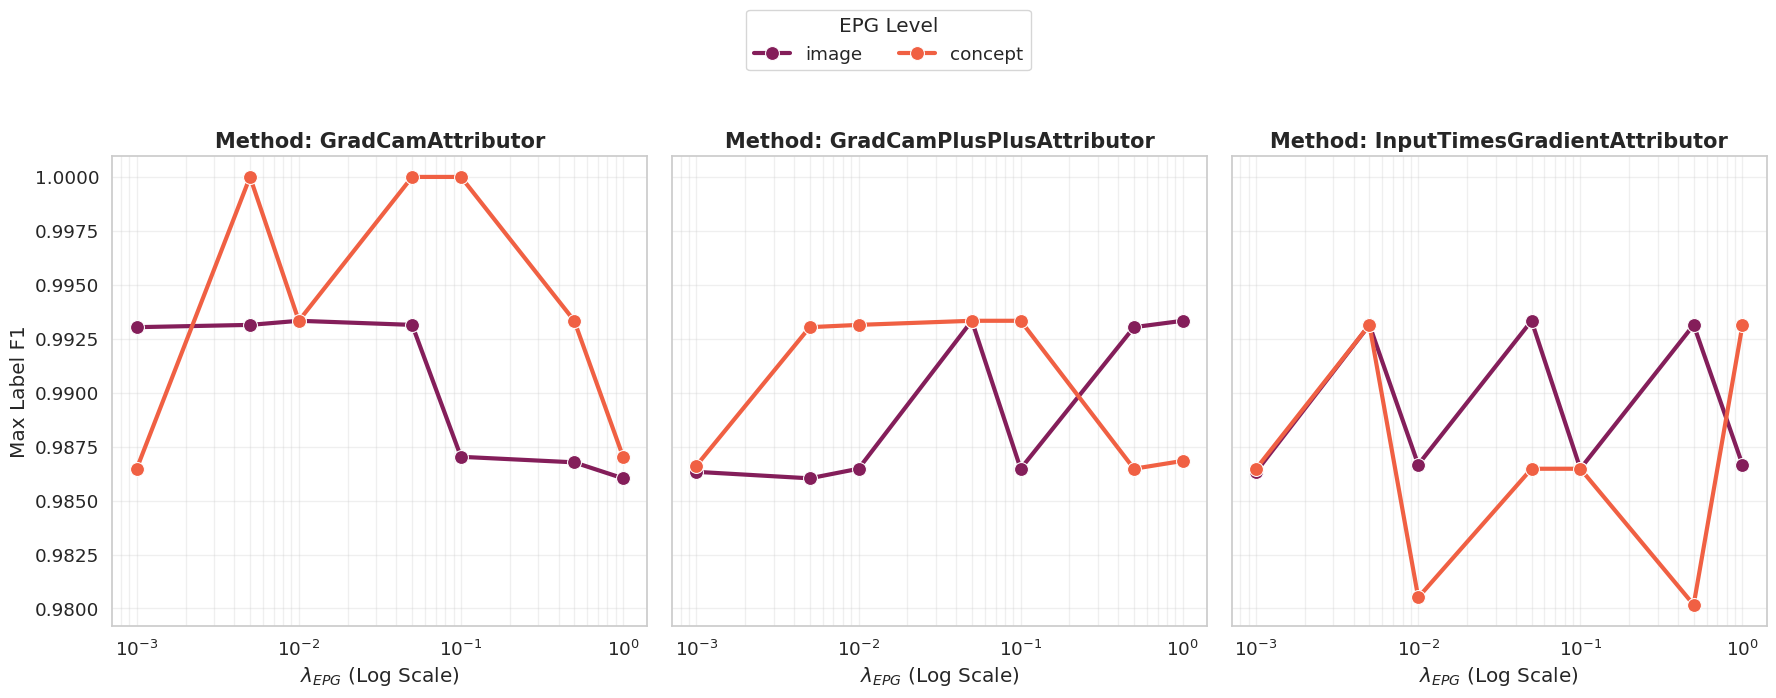

In [37]:
plot_lambda_impact_comparison(summary, "Max Label F1")

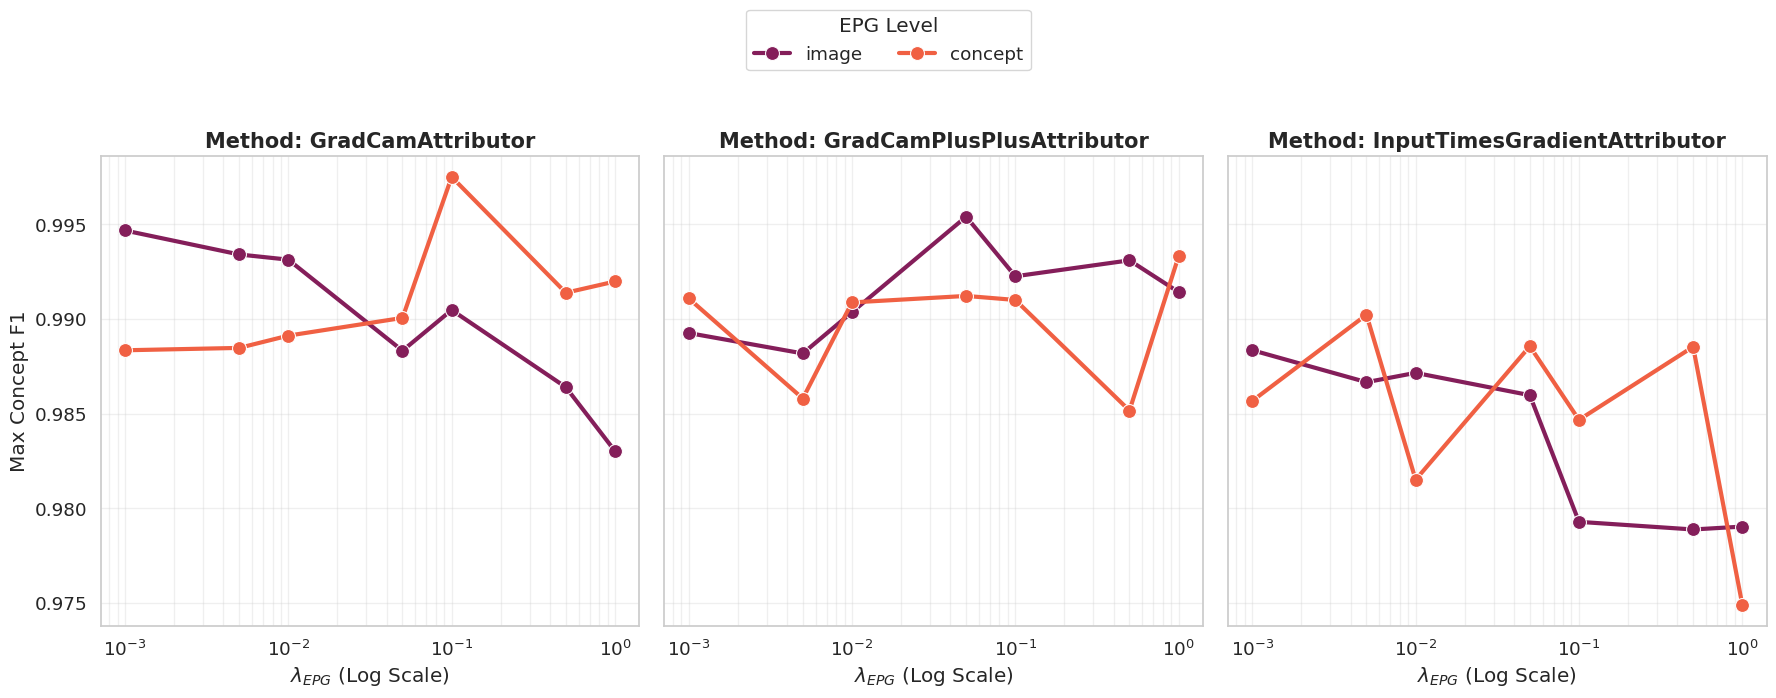

In [40]:
plot_lambda_impact_comparison(summary, "Max Concept F1")

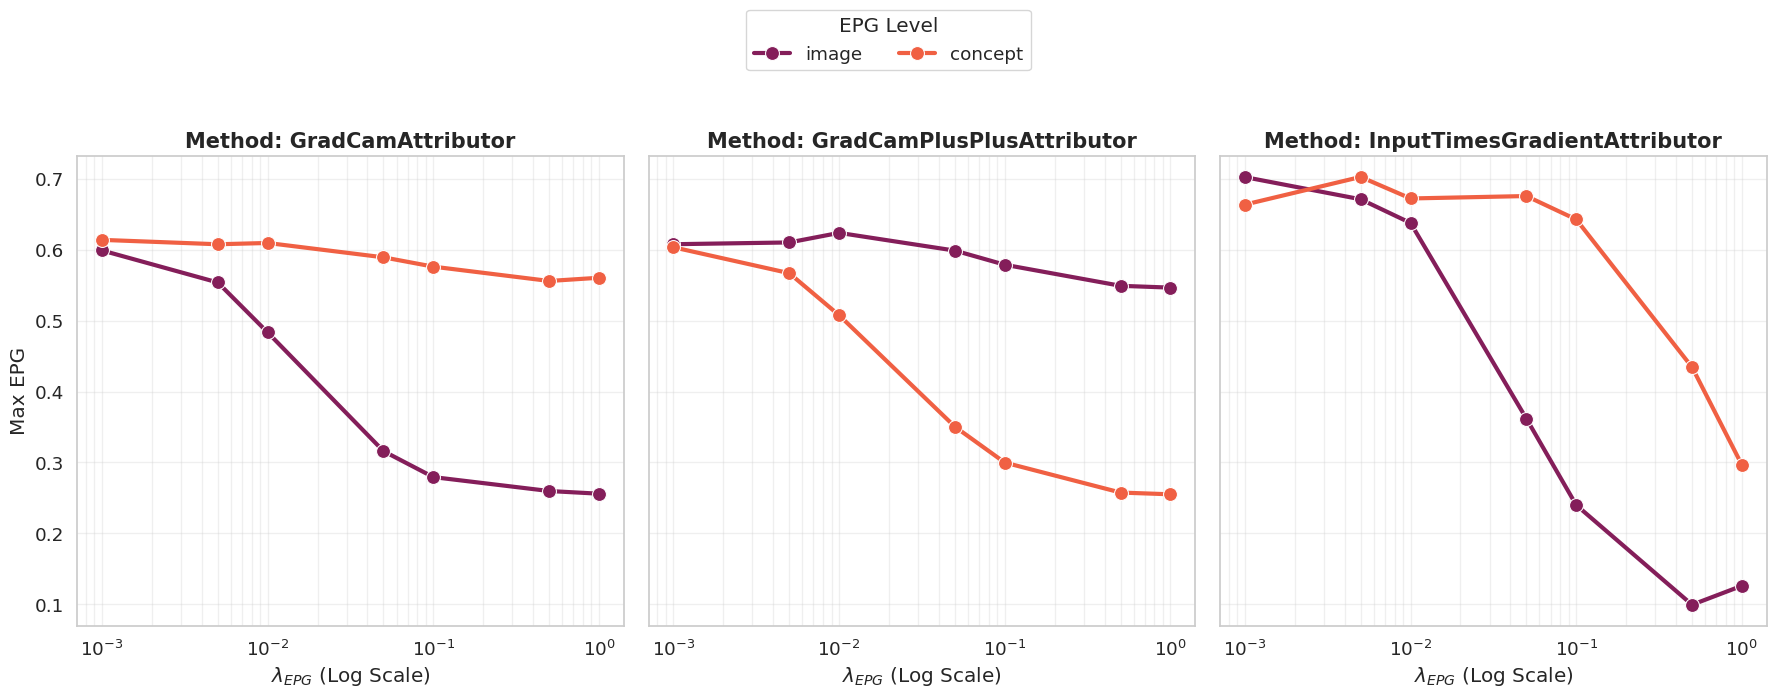

In [44]:
plot_lambda_impact_comparison(summary, "Max EPG")

In [57]:
def analyze_normalized_runtimes(df):
    """Berechnet die durchschnittliche Dauer pro Epoche und skaliert auf 25 Epochen."""
    print("\n--- Laufzeit-Analyse (skaliert auf 25 Epochen) ---")
    
    results = []
    
    # Wir schauen uns jeden Run einzeln an
    for run_id in df['run_id'].unique():
        run_data = df[df['run_id'] == run_id].sort_values('normalized_epoch')
        
        if len(run_data) < 2:
            continue
            
        # Dauer pro Epoche berechnen: Gesamtlaufzeit / Anzahl der geloggten Epochen
        # (Das fängt unterschiedliche Logging-Intervalle am stabilsten ab)
        total_time = run_data['_runtime'].max() - run_data['_runtime'].min()
        num_epochs = run_data['normalized_epoch'].max() - run_data['normalized_epoch'].min()
        
        if num_epochs > 0:
            time_per_epoch = total_time / num_epochs
            projected_time_25 = (time_per_epoch * 25) / 60  # In Minuten für 25 Epochen
            
            results.append({
                'run_id': run_id,
                'attributor': run_data['attributor'].iloc[0],
                'time_per_epoch_sec': time_per_epoch,
                'projected_25_min': projected_time_25
            })
            
    runtime_df = pd.DataFrame(results)
    
    # Statistik pro Attributor berechnen
    stats = runtime_df.groupby('attributor')['projected_25_min'].agg(['mean', 'std']).reset_index()
    
    # Schönere Darstellung
    stats['Display (Mean ± STD)'] = stats.apply(
        lambda x: f"{x['mean']:.2f} min (± {x['std']:.2f})" if pd.notnull(x['std']) else f"{x['mean']:.2f} min", 
        axis=1
    )
    
    print(stats[['attributor', 'Display (Mean ± STD)']].to_string(index=False))
    
    # Plot zur Visualisierung der Rechenkosten
    plot_runtime_comparison(stats)
    
    return stats

def plot_runtime_comparison(stats):
    """Visualisiert die projizierte Laufzeit als Barplot."""
    plt.figure(figsize=(10, 6))
    sns.barplot(data=stats, x='attributor', y='mean', palette='magma', capsize=.1)
    plt.errorbar(x=range(len(stats)), y=stats['mean'], yerr=stats['std'], fmt='none', c='black')
    
    plt.title("Projizierte Rechenzeit für 25 Epochen", fontsize=14, fontweight='bold')
    plt.ylabel("Zeit in Minuten")
    plt.xlabel("Attribution Method")
    plt.tight_layout()
    plt.savefig("projected_runtime_comparison.pdf")
    plt.show()


--- Laufzeit-Analyse (skaliert auf 25 Epochen) ---
                  attributor   Display (Mean ± STD)
           GradCamAttributor   262.47 min (± 78.43)
   GradCamPlusPlusAttributor   261.76 min (± 61.05)
InputTimesGradientAttributor 3457.12 min (± 209.65)


/scratch/ipykernel_493863/527262051.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x='attributor', y='mean', palette='magma', capsize=.1)


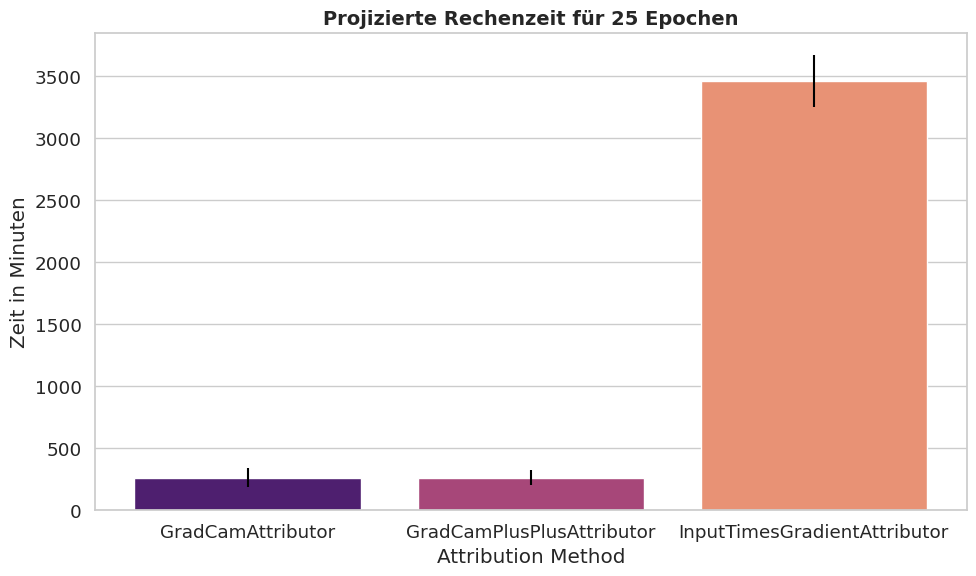

In [59]:
stats = analyze_normalized_runtimes(data)